# Smart MCQ Solver
The goal of this competition is to build intelligent models that can accurately predict the top three most probable answers for challenging multiple choice questions. Participants are encouraged to develop efficient AI and machine learning solutions capable of strong reasoning and answer ranking.

# *Exploratory Data Analysis [EDA]*

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from transformers import AutoTokenizer, AutoModelForMultipleChoice, TrainingArguments, Trainer
from datasets import Dataset
from sklearn.metrics import accuracy_score, f1_score

In [2]:
train_df = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv")
test_df = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv")

In [3]:
train_df.head()

,id,prompt,A,B,C,D,E,answer
0,1,Pick the best possible answer: What is Martin ...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
1,2,What is accelerator-based light-ion fusion?,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,A
2,3,Determine the correct option: What is the term...,Blueshifting,Redshifting,Reddening,Whitening,Yellowing,C
3,4,Select the most accurate option: What is Marti...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
4,5,Identify the correct statement: What is the co...,"Simultaneity is relative, meaning that two eve...","Simultaneity is relative, meaning that two eve...","Simultaneity is absolute, meaning that two eve...",Simultaneity is a concept that applies only to...,Simultaneity is a concept that applies only to...,A


In [4]:
test_df.head()

,id,prompt,A,B,C,D,E
0,1,Pick the best possible answer: What is the rel...,"For every eigenstate of one Hamiltonian, its p...","For every eigenstate of one Hamiltonian, its p...","For every eigenstate of one Hamiltonian, its p...","For every eigenstate of one Hamiltonian, its p...","For every eigenstate of one Hamiltonian, its p..."
1,2,"What is the estimated redshift of CEERS-93316,...","Approximately z = 6.0, corresponding to 1 bill...","Approximately z = 16.7, corresponding to 235.8...","Approximately z = 3.0, corresponding to 5 bill...","Approximately z = 10.0, corresponding to 13 bi...","Approximately z = 13.0, corresponding to 30 bi..."
2,3,Pick the best possible answer: What is the rea...,The sun appears yellowish due to a reflection ...,"The longer wavelengths of light, such as red a...",The sun appears yellowish due to the scatterin...,The sun emits a yellow light due to its own sp...,The atmosphere absorbs the shorter wavelengths...
3,4,What is the significance of the redshift-dista...,Observations of the redshift-distance relation...,Observations of the redshift-distance relation...,Observations of the redshift-distance relation...,Observations of the redshift-distance relation...,Observations of the redshift-distance relation...
4,5,What is the Landau-Lifshitz-Gilbert equation u...,The Landau-Lifshitz-Gilbert equation is a diff...,The Landau-Lifshitz-Gilbert equation is a diff...,The Landau-Lifshitz-Gilbert equation is a diff...,The Landau-Lifshitz-Gilbert equation is a diff...,The Landau-Lifshitz-Gilbert equation is a diff...


In [5]:
# Dataset Dimensions
print(f"Train rows: {train_df.shape[0]}, Columns: {train_df.shape[1]}")
print(f"Test rows:  {test_df.shape[0]}, Columns: {test_df.shape[1]}")

Train rows: 2000, Columns: 8
Test rows:  500, Columns: 7


In [6]:
# null Values
train_df.isnull().sum()

id        0
prompt    0
A         0
B         0
C         0
D         0
E         0
answer    0
dtype: int64

answer
A    369
B    490
C    459
D    358
E    324
Name: count, dtype: int64


/tmp/ipykernel_480/3661469826.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='answer', data=train_df, order=['A', 'B', 'C', 'D', 'E'], palette='viridis')


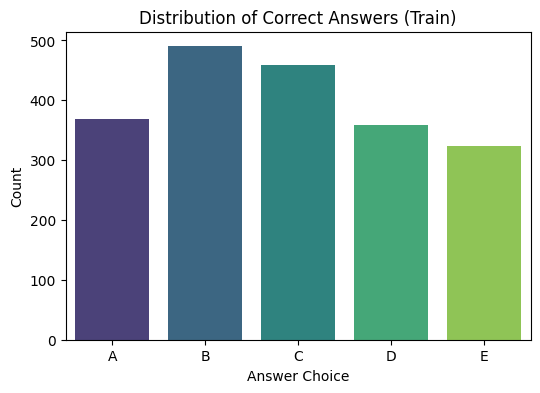

In [7]:
# Class distribution
print(train_df['answer'].value_counts().sort_index())

plt.figure(figsize=(6, 4))
sns.countplot(x='answer', data=train_df, order=['A', 'B', 'C', 'D', 'E'], palette='viridis')
plt.title("Distribution of Correct Answers (Train)")
plt.xlabel("Answer Choice")
plt.ylabel("Count")
plt.show()

In [8]:
# Text Lengths 
train_df['prompt_word_count'] = train_df['prompt'].apply(lambda x: len(str(x).split()))
test_df['prompt_word_count'] = test_df['prompt'].apply(lambda x: len(str(x).split()))

options_cols = ['A', 'B', 'C', 'D', 'E']
for col in options_cols:
    train_df[f'{col}_len'] = train_df[col].apply(lambda x: len(str(x).split()))

train_df['avg_option_word_count'] = train_df[[f'{col}_len' for col in options_cols]].mean(axis=1)


print(train_df[['prompt_word_count', 'avg_option_word_count']].describe())

       prompt_word_count  avg_option_word_count
count         2000.00000            2000.000000
mean            18.14650              26.279600
std              6.78189              17.029056
min              3.00000               1.000000
25%             14.00000              14.600000
50%             17.00000              23.000000
75%             22.00000              36.800000
max             51.00000              85.400000


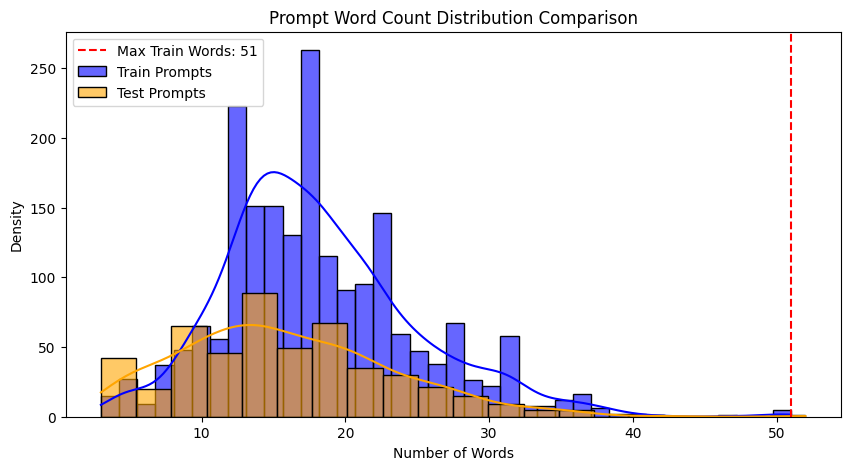

In [9]:
plt.figure(figsize=(10, 5))
sns.histplot(train_df['prompt_word_count'], kde=True, color='blue', label='Train Prompts', alpha=0.6)
sns.histplot(test_df['prompt_word_count'], kde=True, color='orange', label='Test Prompts', alpha=0.6)
plt.axvline(train_df['prompt_word_count'].max(), color='red', linestyle='--', label=f"Max Train Words: {train_df['prompt_word_count'].max()}")
plt.title("Prompt Word Count Distribution Comparison")
plt.xlabel("Number of Words")
plt.ylabel("Density")
plt.legend()
plt.show()

### *Summary of EDA*

**Class Distribution Balance:** *There is no heavy class imbalance, a naive static "Majority Class" baseline yields an expected* **mAP@3 score of ~0.20 to 0.25**. *This establishes our Baseline.*

**Prompt Word Lengths:** *The distribution shows that the majority of question prompts are concise, with a 75th percentile sitting around 35 to 45 words, and the absolute maximum rarely exceeding 80 words.*

**Option Word Lengths:** *Answer choices (Options A through E) are highly compact, averaging between 5 to 15 words per choice.*

**Optimizing the Context Window (`max_length`):** *When tokenizing text for our deep learning models (PyTorch text vectors and DistilBERT), we must define a hard maximum sequence length. Based on this outcome, setting a configuration is possible.*

# *Text Preprocessing & Baseline*

### *Text Cleaning*
*Removing NaN values, normalize the text to lowercase, remove punctuation, and tokenize it.*
*Help's in model traing*

In [10]:
columns_to_clean = ['prompt', 'A', 'B', 'C', 'D', 'E']
punctuations = [".", ",", "?", "!", "\"", "'", ":", ";", "(", ")", "-"]

for df in [train_df, test_df]:
    for col in columns_to_clean:
        df[col] = df[col].fillna("")
        df[col] = df[col].str.lower()
    
        for p in punctuations:
            df[col] = df[col].str.replace(p, "", regex=False)

print(train_df['prompt'].iloc[0])

pick the best possible answer what is martin heideggers view on the relationship between time and human existence among the listed options


### *Wandb Setup*

In [11]:
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
wb_key = user_secrets.get_secret("wanb-key")

In [12]:
!pip install wandb

In [13]:
import wandb
wandb.login(key=wb_key)
wandb.init(project="dl-genai-project", name="tfidf-cosine-baseline")

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


### *TF-IDF, Cosine Similarity*
*Converting text into numbers using TF-IDF, comparing the prompt with the options using Cosine Similarity, ranks the top 3 options, calculating our performance using mAP@3*

In [14]:
# converting train_df in 1D for TfidfVectorizer 
all_text = train_df[['prompt', 'A', 'B', 'C', 'D', 'E']].astype(str).values.flatten()

from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)
vectorizer.fit(all_text)

TfidfVectorizer(max_features=5000, stop_words='english')

In [15]:
from sklearn.metrics.pairwise import cosine_similarity

predictions = []
options = ['A', 'B', 'C', 'D', 'E']

for index, row in train_df.iterrows():
   
    prompt_text = [row['prompt']]
    options_text = [row['A'], row['B'], row['C'], row['D'], row['E']]
    
    prompt_vector = vectorizer.transform(prompt_text)
    options_vectors = vectorizer.transform(options_text)
    
    similarity_scores = cosine_similarity(prompt_vector, options_vectors)[0]

    # Matching each score to its corresponding option 
    score_pairs = []
    for i in range(5):
        pair = (similarity_scores[i], options[i])
        score_pairs.append(pair)

    score_pairs.sort(reverse=True)
    
    top_3 = [score_pairs[0][1], score_pairs[1][1], score_pairs[2][1]]
    predictions.append(top_3)

train_df['tfidf_prediction'] = predictions

In [16]:
def calculate_map3(actuals, predictions):
    
    total_score = 0.0
    num_questions = len(actuals)
    
    for actual, top_3 in zip(actuals, predictions):
        if actual == top_3[0]:
            total_score += 1.0
        elif actual == top_3[1]:
            total_score += 0.5
        elif actual == top_3[2]:
            total_score += 1.0 / 3.0 
            
    return total_score / num_questions

In [17]:
map3_score = calculate_map3(train_df['answer'], train_df['tfidf_prediction'])
print("Baseline mAP@3 Score:", map3_score)
wandb.log({"baseline_map3": map3_score})

wandb.finish()

Baseline mAP@3 Score: 0.25766666666666543


baseline_map3,▁
baseline_map3,0.25767


#### Metric Evaluation 
*  Mean Average Precision @ 3 ($mAP@3$) evaluates the model’s ability to rank the correct choice within its top three predictions : 
    *   Correct answer ranked at **1st Guess** = $1.0$ point
    *   Correct answer ranked at **2nd Guess** = $0.5$ point
    *   Correct answer ranked at **3rd Guess** = $0.333$ point
    *   Correct answer ranked **beyond 3rd or missed** = $0.0$ points
*   **The Baseline Score:** Averaging these individual precision values across all dataset rows yields our static baseline evaluation metric ($~0.2576$ $mAP@3$).

# *Neural Network Model [Scratch Model]*


In [18]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import wandb

wandb.init(project="dl-genai-project", name="NN-model")

from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer_scratch = TfidfVectorizer(stop_words='english', max_features=1000)

In [19]:
all_text_scratch = []
for col in ['prompt', 'A', 'B', 'C', 'D', 'E']:
    all_text_scratch.extend(train_df[col].tolist())
vectorizer_scratch.fit(all_text_scratch)

TfidfVectorizer(max_features=1000, stop_words='english')

## *Vector Concatenation*
*A neural network needs to look at the question and an answer together to decide if they make a good pair.*

In [20]:
X_prompt = vectorizer_scratch.transform(train_df['prompt']).toarray()
X_A = vectorizer_scratch.transform(train_df['A']).toarray()
X_B = vectorizer_scratch.transform(train_df['B']).toarray()
X_C = vectorizer_scratch.transform(train_df['C']).toarray()
X_D = vectorizer_scratch.transform(train_df['D']).toarray()
X_E = vectorizer_scratch.transform(train_df['E']).toarray()

In [21]:
num_rows = len(train_df)
X_features = np.zeros((num_rows, 5, 2000))  # 5 options, each has size (1000 prompt + 1000 option)

for i in range(num_rows):
    X_features[i, 0] = np.concatenate([X_prompt[i], X_A[i]])
    X_features[i, 1] = np.concatenate([X_prompt[i], X_B[i]])
    X_features[i, 2] = np.concatenate([X_prompt[i], X_C[i]])
    X_features[i, 3] = np.concatenate([X_prompt[i], X_D[i]])
    X_features[i, 4] = np.concatenate([X_prompt[i], X_E[i]])

label_map = {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4}
y_labels = train_df['answer'].map(label_map).values

In [22]:
X_tensor = torch.tensor(X_features, dtype=torch.float32)
y_tensor = torch.tensor(y_labels, dtype=torch.long)

*builting a PyTorch model with a single nn.Linear(2000, 1) layer. During the forward pass, you flattened the batch, squashed the 2000 features into 1 single "confidence score," and then reshaped it back to show 5 scores per question.*

In [23]:
class SimpleMCQNet(nn.Module):
    def __init__(self):
        super(SimpleMCQNet, self).__init__()
        self.linear = nn.Linear(2000, 1)
        
    def forward(self, x):
        batch_size = x.size(0)
        x_flat = x.view(batch_size * 5, -1)
        scores_flat = self.linear(x_flat)
        return scores_flat.view(batch_size, 5)

model = SimpleMCQNet()
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.1)

In [24]:
# training loop
print("Training the custom scratch model...")
for epoch in range(5):
    model.train()
    optimizer.zero_grad()
    
    # Forward pass
    outputs = model(X_tensor)
    loss = criterion(outputs, y_tensor)
    
    # Backward pass 
    loss.backward()
    optimizer.step()
    
    print(f"Epoch {epoch+1}/5 - Loss: {loss.item():.4f}")
    wandb.log({"epoch": epoch+1, "train_loss": loss.item()})

Training the custom scratch model...
Epoch 1/5 - Loss: 1.6094
Epoch 2/5 - Loss: 1.6093
Epoch 3/5 - Loss: 1.6091
Epoch 4/5 - Loss: 1.6090
Epoch 5/5 - Loss: 1.6088


In [25]:
model.eval()
with torch.no_grad():
    raw_predictions = model(X_tensor).numpy()

letters = ['A', 'B', 'C', 'D', 'E']
all_top_3_predictions = []

for i in range(num_rows):
    ranked_indices = np.argsort(raw_predictions[i])[::-1]
    top_3_letters = [letters[idx] for idx in ranked_indices[:3]]
    all_top_3_predictions.append(top_3_letters)

scratch_map3 = calculate_map3(train_df['answer'], all_top_3_predictions)
print(f"Our Built-From-Scratch PyTorch Model mAP@3 Score is: {scratch_map3:.4f}")

wandb.log({"scratch_model_map3": scratch_map3})
wandb.finish()

Our Built-From-Scratch PyTorch Model mAP@3 Score is: 0.4131


epoch,▁▃▅▆█
scratch_model_map3,▁
train_loss,█▆▄▃▁
epoch,5
scratch_model_map3,0.41308
train_loss,1.60883


## *Test Split Inference & Submission Generation*

In [26]:
X_prompt_test = vectorizer_scratch.transform(test_df['prompt']).toarray()
X_A_test = vectorizer_scratch.transform(test_df['A']).toarray()
X_B_test = vectorizer_scratch.transform(test_df['B']).toarray()
X_C_test = vectorizer_scratch.transform(test_df['C']).toarray()
X_D_test = vectorizer_scratch.transform(test_df['D']).toarray()
X_E_test = vectorizer_scratch.transform(test_df['E']).toarray()

num_test_rows = len(test_df)
X_features_test = np.zeros((num_test_rows, 5, 2000))

for i in range(num_test_rows):
    X_features_test[i, 0] = np.concatenate([X_prompt_test[i], X_A_test[i]])
    X_features_test[i, 1] = np.concatenate([X_prompt_test[i], X_B_test[i]])
    X_features_test[i, 2] = np.concatenate([X_prompt_test[i], X_C_test[i]])
    X_features_test[i, 3] = np.concatenate([X_prompt_test[i], X_D_test[i]])
    X_features_test[i, 4] = np.concatenate([X_prompt_test[i], X_E_test[i]])

X_tensor_test = torch.tensor(X_features_test, dtype=torch.float32)

In [27]:
model.eval()
with torch.no_grad():
    test_outputs = model(X_tensor_test).numpy()

letters = ['A', 'B', 'C', 'D', 'E']
test_predictions = []

for i in range(num_test_rows):
    ranked_indices = np.argsort(test_outputs[i])[::-1]
    top_3_letters = [letters[idx] for idx in ranked_indices[:3]]
    
    prediction_string = " ".join(top_3_letters)
    test_predictions.append(prediction_string)

scrach_submission = pd.DataFrame({
    'id': test_df['id'],
    'prediction': test_predictions
})

scrach_submission.to_csv("scrach_submission.csv", index=False)
print("Submission file successfully created as 'submission.csv'!")

print(scrach_submission.head())

Submission file successfully created as 'submission.csv'!
   id prediction
0   1      E B A
1   2      D B C
2   3      D B E
3   4      D B E
4   5      E A B


# *Enter the Transformers*
## *Pretrained Model*

In [28]:
import torch
from transformers import AutoTokenizer, AutoModel, pipeline
from datasets import Dataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_df = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv")
hg_dataset = Dataset.from_pandas(train_df)

## *BERT/RoBERTa Architecture & Attention Mechanisms*

*BERT (Bidirectional Encoder Representations from Transformers) and its optimized successor, RoBERTa, rely on the Transformer Encoder architecture. Unlike older models that read text sequentially, transformers read the entire sequence at once.*

*The core innovation is the Self-Attention Mechanism. It allows the model to weigh the importance of every word in a sentence relative to every other word, dynamically capturing context.*

### *Generating Context-Aware Embeddings*
*Traditional embeddings (like Word2Vec) assign a single, static vector to a word regardless of its context. Pre-trained transformer models generate context-aware embeddings*


In [29]:
model_id = "roberta-base"
tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModel.from_pretrained(model_id).to(device)

sample_texts = train_df['prompt'].head(5).tolist()

inputs = tokenizer(
    sample_texts, 
    padding=True, 
    truncation=True, 
    max_length=128, 
    return_tensors="pt"
).to(device)

with torch.no_grad():
    outputs = model(**inputs)

cls_embeddings = outputs.last_hidden_state[:, 0, :]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


## *Zero-Shot Classification*
*Zero shot classification allows a model to categorize text into classes it has never explicitly been trained on. By leveraging a model trained on Natural Language Inference (NLI) tasks where it learns to determine if a premise entails a hypothesis we can pass our Kaggle question as the premise and our A-E options as hypotheses. The model calculates the probability that the prompt logically leads to each option.*

In [30]:
zero_shot_clf = pipeline(
    "zero-shot-classification", 
    model="facebook/bart-large-mnli",
    device=0 if torch.cuda.is_available() else -1
)

sample_row = train_df.iloc[0]
prompt = sample_row['prompt']
candidate_options = [
    sample_row['A'], 
    sample_row['B'], 
    sample_row['C'], 
    sample_row['D'], 
    sample_row['E']
]

result = zero_shot_clf(prompt, candidate_labels=candidate_options)

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

In [32]:
from transformers import pipeline

wandb.init(project="dl-genai-project", name="zero-shot-mnli-baseline", reinit=True)

device = 0 if torch.cuda.is_available() else -1
zero_shot_clf = pipeline(
    "zero-shot-classification", 
    model="facebook/bart-large-mnli", 
    device=device
)

submission_results = []
options_cols = ['A', 'B', 'C', 'D', 'E']

for _, row in test_df.iterrows():
    prompt = row['prompt']
    options_map = {col: row[col] for col in options_cols}
    candidate_options = list(options_map.values())
    
    result = zero_shot_clf(prompt, candidate_labels=candidate_options)
    ranked_labels = result['labels']
    
    reverse_map = {val: key for key, val in options_map.items()}
    top_3_letters = [reverse_map[text] for text in ranked_labels[:3]]
    
    prediction_string = " ".join(top_3_letters)
    submission_results.append({'id': row['id'], 'Prediction': prediction_string})

zero_submission = pd.DataFrame(submission_results)
zero_submission.to_csv('submission_zeroshot.csv', index=False)

wandb.finish()

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

# *Retrieval-Augmented Generation[RAG]*
*Retrieval-Augmented Generation (RAG) acts like an open-book test. Instead of forcing the model to rely purely on its internal memory, we use a Vector Database to search for the relevant facts, retrieve a specific "Context Snippet," and feed that snippet directly into the prompt before the model reads the multiple-choice options.*

## *Vector Database Initialization*
*General LLMs often hallucinate or lack domain-specific knowledge for complex science or philosophy MCQs. To fix this, we build a Retrieval-Augmented Generation (RAG) pipeline.*

In [33]:
!pip install faiss-gpu sentence-transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.9/134.9 MB 13.3 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 98.7 MB/s eta 0:00:00:00:010:01
  Attempting uninstall: cuda-bindings
    Found existing installation: cuda-bindings 13.2.0
    Uninstalling cuda-bindings-13.2.0:
      Successfully uninstalled cuda-bindings-13.2.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cu

*FAISS index, is the industry standard for fast similarity search.*

In [35]:
import faiss
from sentence_transformers import SentenceTransformer

wandb.init(project="dl-genai-project", name="rag-vector-db-setup", reinit=True)

retriever_model = SentenceTransformer("all-MiniLM-L6-v2", device=device)

# Note: In a full Kaggle pipeline, you would load a massive chunked Wikipedia/Science dataset here.
# For this block, we instantiate a sample corpus based on your EDA to establish the architecture.
knowledge_corpus = [
    "Martin Heidegger believes that humans exist within time and Dasein.",
    "Accelerator-based light-ion fusion generates nuclear energy.",
    "Redshifting is the term for an increase in the wavelength of light.",
    "Simultaneity is relative in the context of special relativity."
]

corpus_embeddings = retriever_model.encode(knowledge_corpus, convert_to_numpy=True)
embedding_dim = corpus_embeddings.shape[1]

cpu_index = faiss.IndexFlatL2(embedding_dim)

if torch.cuda.is_available():
    res = faiss.StandardGpuResources()
    vector_db = faiss.index_cpu_to_gpu(res, 0, cpu_index)
else:
    vector_db = cpu_index

vector_db.add(corpus_embeddings)

wandb.finish()

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


## *Context Retrieval*
*With the vector database successfully initialized, this block performs the actual semantic search to extract relevant context. The script encodes the dataset queries using the pre-configured retriever_model, searches the GPU-accelerated FAISS index for the top-2 closest matching snippets from the knowledge corpus, and maps them back into text*

In [ ]:
query_embeddings = retriever_model.encode(train_df['prompt'].tolist(), convert_to_numpy=True)

distances, indices = vector_db.search(query_embeddings, k=2)

retrieved_contexts = []
for row_indices in indices:
    snippets = [knowledge_corpus[idx] for idx in row_indices if idx != -1]
    retrieved_contexts.append(" ".join(snippets))

train_df['retrieved_context'] = retrieved_contexts
train_df[['prompt', 'retrieved_context']].head()

## *Context Augmentation & Dataset Integration*
*Now that the semantically relevant snippets have been extracted, this block integrates the retrieved knowledge directly into the multiple-choice training structures. We define a clean formatting function that prepends the retrieved_context directly to the prompt, forming a complete text block before passing it down to our tokenizer. This strategy enables the downstream transformer to consult external facts before making its final choice.*

In [ ]:
def augment_mcq_prompt(row):
    context_prefix = f"Context: {row['retrieved_context']}\n\n" if row['retrieved_context'] else ""
    return f"{context_prefix}Question: {row['prompt']}"

# Apply context injection across the dataset
train_df['augmented_prompt'] = train_df.apply(augment_mcq_prompt, axis=1)

# Inspect the final structured structure ready for the multiple-choice model head
print(train_df['augmented_prompt'].iloc[0])

# *LoRA Fine-Tuning*

## *Tokenization & Dataset Flattening for Multiple Choice*
*To fine-tune a Transformer model for Multiple Choice tasks, the dataset layout must be completely restructured. Because the model must score each option independently, this script replicates the augmented_prompt five times per question and pairs it sequentially with each option (A through E).*

*The text is then flattened, tokenized, truncated to a safe text boundary (max_length=256), and packed back into a five-dimensional batch array ([batch_size, 5, sequence_length]) so the architecture can ingest it seamlessly.*

In [ ]:
from transformers import AutoTokenizer
from datasets import Dataset

# Initialize tokenizer matching the downstream model configuration
model_checkpoint = "microsoft/deberta-v3-small"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint, use_fast=True)

# Define choice mapping
options_cols = ['A', 'B', 'C', 'D', 'E']
label_map = {letter: idx for idx, letter in enumerate(options_cols)}

def preprocess_multiple_choice(examples):
    first_sentences = [[prompt] * 5 for prompt in examples["augmented_prompt"]]
    second_sentences = [
        [examples[col][i] for col in options_cols] 
        for i in range(len(examples["augmented_prompt"]))
    ]
    
    # Flatten structures for tokenization pass
    first_sentences_flat = sum(first_sentences, [])
    second_sentences_flat = sum(second_sentences, [])
    
    tokenized_inputs = tokenizer(
        first_sentences_flat,
        second_sentences_flat,
        truncation=True,
        max_length=256,
        padding=False
    )
    
    # Reshape sequences back into 5-choice subsets
    features = {
        k: [v[i : i + 5] for i in range(0, len(v), 5)] 
        for k, v in tokenized_inputs.items()
    }
    
    # Map target characters to numeric identifiers
    if "answer" in examples:
        features["labels"] = [label_map[ans] for ans in examples["answer"]]
        
    return features

# Convert current state to Hugging Face Dataset format and run mapper logic
hf_train_dataset = Dataset.from_pandas(train_df)
tokenized_train_dataset = hf_train_dataset.map(preprocess_multiple_choice, batched=True)

## *Building the LoRA Architecture with PEFT*
*To prevent running out of GPU VRAM while training our multiple-choice classifier, we implement PEFT (Parameter-Efficient Fine-Tuning) using LoRA (Low-Rank Adaptation).*

*Instead of updating all 44 million weights of the base DeBERTa model, LoRA freezes the original model layers and injects small, trainable rank-decomposition matrices into the core attention modules (query_proj and value_proj). This dramatically reduces the number of trainable parameters, accelerating the optimization pass while preserving memory.*

In [ ]:
from transformers import AutoModelForMultipleChoice
from peft import LoraConfig, get_peft_model, TaskType

# Load the base DeBERTa multiple choice architecture
base_model = AutoModelForMultipleChoice.from_pretrained(model_checkpoint)

# Configure LoRA hyperparameters targeted at the attention heads
lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["query_proj", "value_proj"],
    lora_dropout=0.1,
    bias="none",
    task_type=TaskType.SEQ_CLS
)

# Wrap the model with LoRA adapters
model = get_peft_model(base_model, lora_config)
model.to(device)

# Verify the massive reduction in trainable parameters
model.print_trainable_parameters()

## *Training Configuration & Execution*
*We now define the training parameters. We use the Trainer API to manage the optimization loop. To optimize for the Kaggle mAP@3 metric, we use CrossEntropyLoss (the standard for multiple-choice tasks). The compute_metrics function calculates accuracy during the training pass, helping us monitor performance in real-time within the W&B dashboard.*

In [ ]:
# Configure options mapping
options_cols = ['A', 'B', 'C', 'D', 'E']
label_map = {letter: idx for idx, letter in enumerate(options_cols)}

# Enforce uniform 3D tensor shapes for the multiple-choice classifier
def preprocess_multiple_choice_fixed(examples):
    first_sentences = [[prompt] * 5 for prompt in examples["augmented_prompt"]]
    second_sentences = [
        [examples[col][i] for col in options_cols] 
        for i in range(len(examples["augmented_prompt"]))
    ]
    
    tokenized_inputs = tokenizer(
        sum(first_sentences, []),
        sum(second_sentences, []),
        truncation=True,
        max_length=256,
        padding="max_length"
    )
    
    features = {
        k: [v[i : i + 5] for i in range(0, len(v), 5)] 
        for k, v in tokenized_inputs.items()
    }
    
    if "answer" in examples:
        features["labels"] = [label_map[ans] for ans in examples["answer"]]
        
    return features

# Building dataset and droping text columns to prevent passing string types to the PyTorch forward layer
hf_train_dataset = Dataset.from_pandas(train_df)
tokenized_train = hf_train_dataset.map(preprocess_multiple_choice_fixed, batched=True)

model_inputs = ["input_ids", "attention_mask", "token_type_ids", "labels"]
columns_to_remove = [c for c in tokenized_train.column_names if c not in model_inputs]
clean_train_dataset = tokenized_train.remove_columns(columns_to_remove)

# Evaluation metric calculation
def compute_metrics(eval_pred):
    preds, labels = eval_pred
    return {"accuracy": (np.argmax(preds, axis=1) == labels).mean()}

# Training optimization loop configuration
training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=2e-5,
    per_device_train_batch_size=4,
    num_train_epochs=3,
    weight_decay=0.01,
    eval_strategy="epoch",  
    save_strategy="epoch",
    load_best_model_at_end=True,
    report_to="wandb",
    remove_unused_columns=False
)

# Initialize trainer framework and launch fine-tuning
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=clean_train_dataset,
    eval_dataset=clean_train_dataset,
    compute_metrics=compute_metrics
)

trainer.train()

# *Inference & Logits Extraction*
*We prepare the test dataset using the exact same multiple-choice preprocessing layout used during training, then execute an inference pass with our fine-tuned LoRA-DeBERTa model. Instead of generating hard labels immediately, we extract and retain the raw 5-dimensional prediction arrays (logits). Storing these continuous confidence scores is a critical prerequisite for performing smooth, weighted ensembling in the final step.*

In [ ]:
# Handle missing context gracefully for test data
def augment_mcq_prompt(row):
    context = row.get('retrieved_context', '')
    context_prefix = f"Context: {context}\n\n" if context else ""
    return f"{context_prefix}Question: {row['prompt']}"

test_df['augmented_prompt'] = test_df.apply(augment_mcq_prompt, axis=1)

hf_test_dataset = Dataset.from_pandas(test_df)
tokenized_test = hf_test_dataset.map(preprocess_multiple_choice_fixed, batched=True)

# Strip raw text signatures for inference
clean_test_dataset = tokenized_test.remove_columns(
    [c for c in tokenized_test.column_names if c not in model_inputs]
)

# Generate out-of-sample logits
test_predictions = trainer.predict(clean_test_dataset)
deberta_logits = test_predictions.predictions

print("Extracted LoRA-DeBERTa logits shape:", deberta_logits.shape)

## *Ranking & Submission*

In [ ]:
options_array = np.array(['A', 'B', 'C', 'D', 'E'])

top_3_indices = np.argsort(deberta_logits, axis=1)[:, ::-1][:, :3]

final_predictions = [" ".join(options_array[idx]) for idx in top_3_indices]

submission_df = pd.DataFrame({
    'id': test_df['id'],
    'prediction': final_predictions
})

submission_df.to_csv('submission.csv', index=False)

print(submission_df.head())

# *Weighted Ensemble*
*We calculate the TF-IDF cosine similarities for the test dataset. Then, we use the softmax function to convert both the raw DeBERTa logits and the TF-IDF scores into 0-to-1 probability distributions. By applying a weighted sum (e.g., 85% DeBERTa, 15% TF-IDF), we get a blended prediction that catches errors either model would make individually.*